In [ ]:
import numpy as np
import pandas as pd

In [159]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.tri import Triangulation

In [68]:
from utils.abcd import M_free, M_focal, stability_condition, eigen_q, waist_and_position

# Propagation matrices

We define below the propagation matrices for different cavities configurations:
- linear cavity (concave-concave, planoconcave)
- circular cavity (bow-tie ring)

### Linear cavities

In [69]:
def concave_concave(roc1, roc2, L, l_crystal, index):
    """
    Linear cavity formed by two curved mirrors
    :param roc1: radius of curvature of mirror 1
    :param roc2: radius of curvature of mirror 2
    :param L: round-trip geometric length of the cavity
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    # Equivalent focal of curved mirrors in reflection
    f1 = roc1 / 2
    f2 = roc2 / 2
    # Geometrical length of propagation in the air
    l_air = L - l_crystal

    # Propagation matrix (starts from mirror 1)
    M = M_focal(f1) @ M_free(l_air/2) @ M_free(l_crystal/index) @ M_free(l_air/2) @ M_focal(f2) @ M_free(l_air/2) @ M_free(l_crystal/index) @ M_free(l_air/2)

    return M

In [70]:
def plano_concave(roc, L, l_crystal, index):
    """
    Linear cavity formed by a curved mirror and a flat mirror.
    Same calculation as concave-concave, but with a roc2 = infty
    :param roc: radius of curvature of mirror
    :param L: round-trip geometric length of the cavity
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    roc2 = np.inf
    return concave_concave(roc1=roc, roc2=roc2, L=L, l_crystal=l_crystal, index=index)

### Ring cavity

In [71]:
def bow_tie(roc1, roc2, L, d_curved, l_crystal, index):
    """
    Bow tie ring cavity
    :param roc1: radius of curvature of mirror 1
    :param roc2: radius of curvature of mirror 2
    :param L: round-trip geometric length of the cavity
    :param d_curved: distance between the curved mirrors
    :param l_crystal: crystal length
    :param index: refractive index of the crystal

    :return: propagation matrix
    """
    # Equivalent focal of curved mirrors in reflection
    f1 = roc1 / 2
    f2 = roc2 / 2

    # Geometrical length of propagation in the air
    l1 = (L - d_curved) / 2  # L = d_curved + d_flat + 2*d_diag
    l2 = (d_curved - l_crystal) / 2

    # Propagation matrix (starts from middle of flat mirrors)
    M = M_free(l1) @ M_focal(f2) @ M_free(l2) @ M_free(l_crystal/index) @ M_free(l2) @ M_focal(f1) @ M_free(l1)

    return M

# Cavity design

We aim at defining cavity designs based on our experiment constraints (namely finesse and bandwidth).
The idea is to define a "sweep" parameter (cavity length $L$, RoC, etc.) and identify the stability region if it exists. Then based on where the $q_0$ parameter has been chosen, we define a full propagation $q$ parameter over the full cavity to find its waist. For the planoconcave cavity, since the waist is located on the flat mirror, we need to find the position of a target waist instead.

In [72]:
wavelength = 780e-9  # 780 nm

In [73]:
l_crystal = 20e-3  # 20 mm
index = 1.84

In [96]:
roc1 = 100e-3  # 100 mm
roc2 = 100e-3  # 100 mm

f1 = roc1 / 2
f2 = roc2 / 2

## Linear cavities

In [75]:
L_linear = np.linspace(start=0, stop=300, num=600, endpoint=True) * 1e-3  # from 0 to 300 mm

### Concave-concave

In [76]:
waist_values = []
z_waist_values = []
L_stable = []

for L in L_linear:
    # Propagation matrix
    M = concave_concave(roc1=roc1, roc2=roc1, L=L, l_crystal=l_crystal, index=index)

    # Compute q parameter at origin of propagation (M1)
    q0 = eigen_q(M)

    if q0 is None:
        continue

    # Propagation along z axis over cavity length
    z_propagation = np.linspace(start=0, stop=L, num=1000)
    q_propagation = q0 + z_propagation

    # Compute the waist profile along the cavity
    w, z = waist_and_position(q_propagation, wavelength)

    # Find the waist and its position
    i0 = np.argmin(w)
    w0 = w[i0]
    z0 = z[i0]

    waist_values.append(w0)
    z_waist_values.append(z0)
    L_stable.append(L)

#### Plot

### Planoconcave

In [77]:
target_waist = 40e-6 # microns
tol = 5e-6 # 5 microns tolerance

In [78]:
waist_values = []
z_waist_values = []
L_stable = [] # for planoconcave, not only do we need stable cavity, but the length also needs to allow a target waist to exist

for L in L_linear:
    # Propagation matrix
    M = plano_concave(roc=roc1, L=L, l_crystal=l_crystal, index=index)

    # Compute q parameter at origin of propagation (M1)
    q0 = eigen_q(M)

    if q0 is None:
        continue

    # Propagation along z axis over cavity length
    z_propagation = np.linspace(start=0, stop=L, num=1000)
    q_propagation = q0 + z_propagation

    # Compute the waist profile along the cavity
    w, z = waist_and_position(q_propagation, wavelength)

    # Find position where beam radius is closest to target
    i_target = np.argmin(np.abs(w - target_waist))

    if np.abs(w[i_target] - target_waist) < tol:
        w_target_found = w[i_target]
        z_target = z_propagation[i_target]

        waist_values.append(w_target_found)
        z_waist_values.append(z_target)
        L_stable.append(L)
    else:
        continue

In [79]:
waists = np.array(waist_values)
z_waists = np.array(z_waist_values)
L_stable = np.array(L_stable)

print(waists)

[4.00046860e-05 4.07490743e-05]


#### Plot

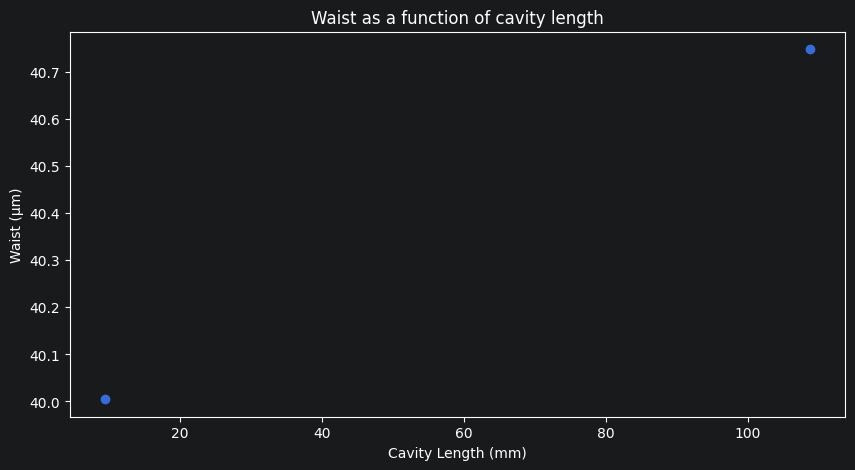

In [80]:
# Plot the waist as a function of the cavity length
plt.figure(figsize=(10, 5))
plt.scatter(L_stable * 1e3, waists * 1e6, label="Waist")
plt.xlabel("Cavity Length (mm)")
plt.ylabel("Waist (µm)")
plt.title("Waist as a function of cavity length")
# plt.legend()
plt.show()

## Bow-tie

The bandwidth of the cavity is determined by its output coupler and length. Based on the colormap of the bandwidth we can set specific range of length to study to match the Rubidium D2 line.
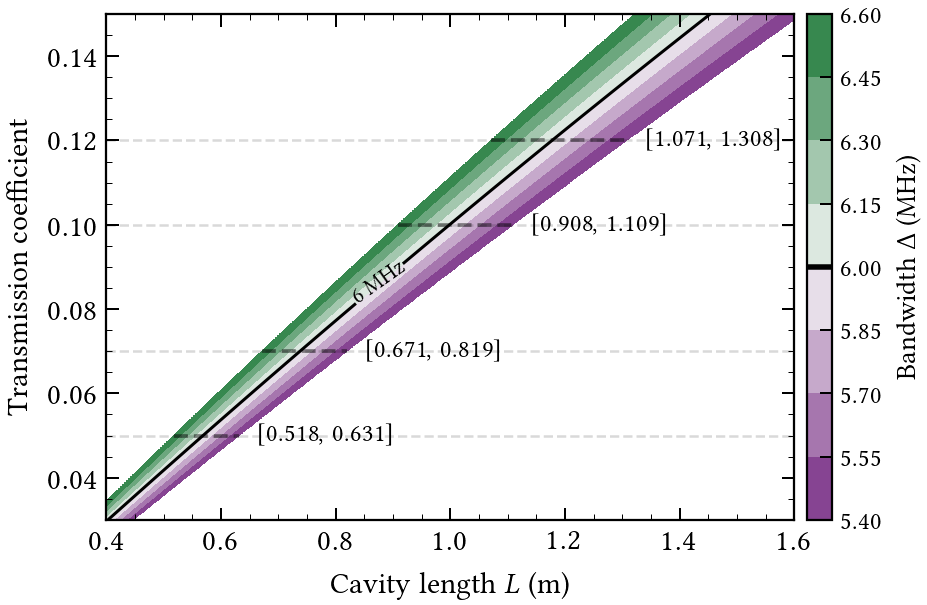

In [113]:
L_ranges = [
    [518, 631],   # T = 5%
    [671, 819],   # T = 7%
    [908, 1109],   # T = 10%
    [1071, 1308],   # T = 12%
]

In [205]:
i = 0 # i between 0 and 3 !
start, stop = L_ranges[i][0], L_ranges[i][1]

# Fixed resolution
dL = 0.2  # mm
npts = int(np.round((stop - start) / dL)) + 1

In [206]:
L_bowtie = np.linspace(start=start, stop=stop, num=npts) * 1e-3 # mm
d_curved_array = np.linspace(start=20, stop=260, num=2000) * 1e-3 # distance between curved mirror (mm)

In [207]:
# Curved mirrors waist
waist1_values = []
z1_waist_values = []

# Flat mirrors waist
waist2_values = []
z2_waist_values = []

L_stable = []
# Each entry is an array corresponding to one L
d_curved_stable = []

for L in L_bowtie:
    d_list = []

    w1_list = []
    z1_list = []

    w2_list = []
    z2_list = []
    for d_curved in d_curved_array:
        # Propagation matrix
        # M = bow_tie(roc1=roc1, roc2=roc1, L=L, d_curved=d_curved, l_crystal=l_crystal, index=index)
        # Geometrical length of propagation in the air
        l1 = (L - d_curved) / 2  # L = d_curved + d_flat + 2*d_diag
        l2 = (d_curved - l_crystal) / 2

        # Round trip matrix starting from flat waist
        M2 = (
            M_free(l1)
            @ M_focal(f2)
            @ M_free(l2)
            @ M_free(l_crystal / index)
            @ M_free(l2)
            @ M_focal(f1)
            @ M_free(l1)
        )

        # Round trip matrix starting from curved waist
        M1 = (
            M_free((l_crystal / 2) / index)
            @ M_free(l2)
            @ M_focal(f1)
            @ M_free(2 * l1)
            @ M_focal(f2)
            @ M_free(l2)
            @ M_free((l_crystal / 2) / index)
        )

        q2 = eigen_q(M2)
        q1 = eigen_q(M1)

        if q1 is None or q2 is None:
            continue

        # Waist between curved mirrors
        w1, z1 = waist_and_position(q1, wavelength)

        # Waist between flat mirrors
        w2, z2 = waist_and_position(q2, wavelength)

        d_list.append(d_curved)

        w1_list.append(w1)
        z1_list.append(z1)

        w2_list.append(w2)
        z2_list.append(z2)

    if len(d_list) > 0:

        L_stable.append(L)
        d_curved_stable.append(np.array(d_list))

        waist1_values.append(np.array(w1_list))
        z1_waist_values.append(np.array(z1_list))

        waist2_values.append(np.array(w2_list))
        z2_waist_values.append(np.array(z2_list))

In [208]:
# How many values of L ?
print("Number of stable cavity lengths: ", len(L_stable))

Number of stable cavity lengths:  566


#### Analysis

On the cavity lengths range, it is possible that the waist obtained will be very similar.

In [197]:
# Analyze how much w1 changes with L and with d_curved
w1_max_list = []
w2_max_list = []
dc_range = []

for i, L in enumerate(L_stable):
    w1 = waist1_values[i] * 1e6
    w2 = waist2_values[i] * 1e6

    idx_max = np.argmax(w1)
    w1_max = w1[idx_max]
    w2_max = w2[idx_max] # not actual max, but corresponding waist for w1 max

    start_dc, stop_dc = d_curved_stable[i][0], d_curved_stable[i][-1]

    w1_max_list.append(w1_max)
    w2_max_list.append(w2_max)
    dc_range.append((start_dc, stop_dc))

w1_max_array = np.array(w1_max_list)
w2_max_array = np.array(w2_max_list)

In [202]:
print("----- w1 max -----")
print(f"Mean   : {np.mean(w1_max_array):.3f} µm")
print(f"Std    : {np.std(w1_max_array):.3f} µm")
print(f"Min    : {np.min(w1_max_array):.3f} µm")
print(f"Max    : {np.max(w1_max_array):.3f} µm")
print(f"Range  : {np.ptp(w1_max_array):.3f} µm")

print("----- corresponding w2 -----")
print(f"Mean   : {np.mean(w2_max_array):.3f} µm")
print(f"Std    : {np.std(w2_max_array):.3f} µm")
print(f"Min    : {np.min(w2_max_array):.3f} µm")
print(f"Max    : {np.max(w2_max_array):.3f} µm")
print(f"Range  : {np.ptp(w2_max_array):.3f} µm")

----- w1 max -----
Mean   : 34.434 µm
Std    : 1.437 µm
Min    : 32.123 µm
Max    : 37.113 µm
Range  : 4.990 µm
----- corresponding w2 -----
Mean   : 252.961 µm
Std    : 10.926 µm
Min    : 233.701 µm
Max    : 270.570 µm
Range  : 36.870 µm


In [203]:
dc_start = np.array([r[0] for r in dc_range]) * 1e3
dc_stop  = np.array([r[1] for r in dc_range]) * 1e3
dc_span  = dc_stop - dc_start

print("----- stable d_c start -----")
print(f"Mean : {np.mean(dc_start):.3f} mm")
print(f"Std  : {np.std(dc_start):.3f} mm")
print(f"Min  : {np.min(dc_start):.3f} mm")
print(f"Max  : {np.max(dc_start):.3f} mm")

print()

print("----- stable d_c stop -----")
print(f"Mean : {np.mean(dc_stop):.3f} mm")
print(f"Std  : {np.std(dc_stop):.3f} mm")
print(f"Min  : {np.min(dc_stop):.3f} mm")
print(f"Max  : {np.max(dc_stop):.3f} mm")

print()

print("----- stable d_c span -----")
print(f"Mean span : {np.mean(dc_span):.3f} mm")
print(f"Std span  : {np.std(dc_span):.3f} mm")
print(f"Min span  : {np.min(dc_span):.3f} mm")
print(f"Max span  : {np.max(dc_span):.3f} mm")

----- stable d_c start -----
Mean : 109.205 mm
Std  : 0.000 mm
Min  : 109.205 mm
Max  : 109.205 mm

----- stable d_c stop -----
Mean : 128.582 mm
Std  : 1.696 mm
Min  : 125.893 mm
Max  : 131.896 mm

----- stable d_c span -----
Mean span : 19.378 mm
Std span  : 1.696 mm
Min span  : 16.688 mm
Max span  : 22.691 mm


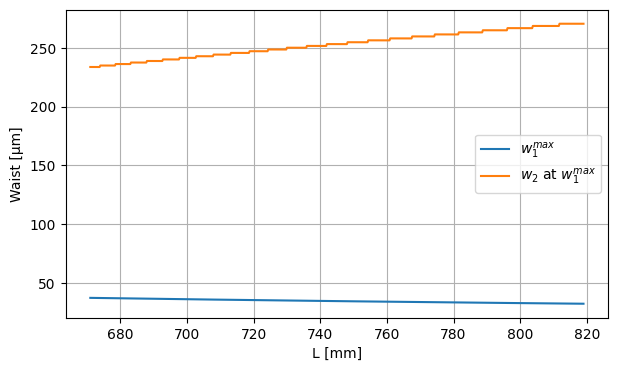

In [200]:
plt.figure(figsize=(7,4))

plt.plot(np.array(L_stable)*1e3, w1_max_array, label=r"$w_1^{max}$")
plt.plot(np.array(L_stable)*1e3, w2_max_list, label=r"$w_2$ at $w_1^{max}$")

plt.xlabel("L [mm]")
plt.ylabel("Waist [µm]")
plt.grid()
plt.legend()

plt.show()

#### Plot

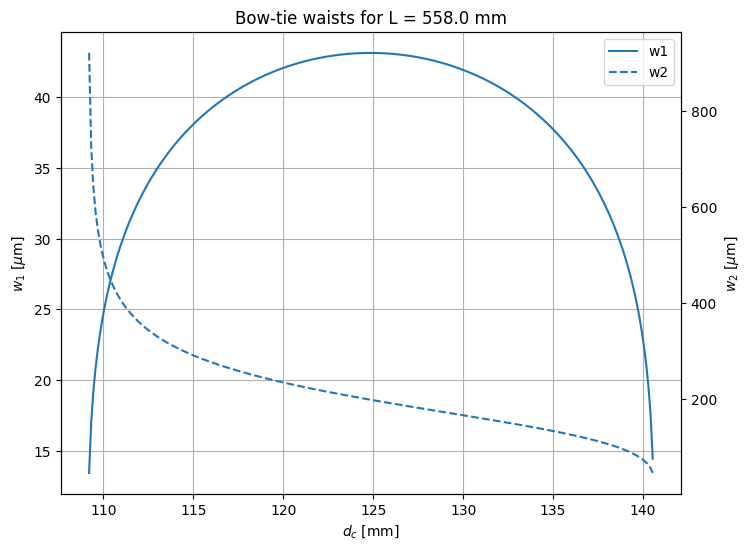

In [209]:
fig, ax1 = plt.subplots(figsize=(8, 6))

i = 200  # fixed L index

# Left axis: w1
ax1.plot(
    d_curved_stable[i] * 1e3,
    waist1_values[i] * 1e6,
    label="w1",
)

ax1.set_xlabel(r"$d_c$ [mm]")
ax1.set_ylabel(r"$w_1$ [$\mu$m]")
ax1.grid()

# Right axis: w2
ax2 = ax1.twinx()

ax2.plot(
    d_curved_stable[i] * 1e3,
    waist2_values[i] * 1e6,
    label="w2",
    linestyle="--",
)

ax2.set_ylabel(r"$w_2$ [$\mu$m]")

# Common title
plt.title(f"Bow-tie waists for L = {L_stable[i]*1e3:.1f} mm")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2)

plt.show()

In [210]:
# Flatten list-of-arrays
L_plot = []
d_plot = []
w1_plot = []

for i, L in enumerate(L_stable):
    L_plot.extend([L] * len(d_curved_stable[i]))
    d_plot.extend(d_curved_stable[i])
    w1_plot.extend(waist1_values[i])

L_plot = np.array(L_plot)
d_plot = np.array(d_plot)
w1_plot = np.array(w1_plot)

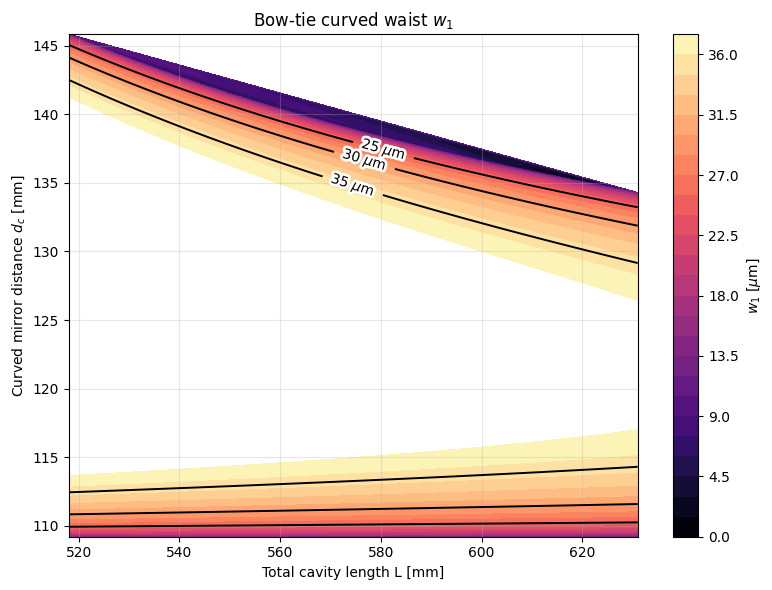

In [211]:
x = L_plot * 1e3
y = d_plot * 1e3
z = w1_plot * 1e6

threshold = 0.0  # µm
mask = z > threshold

x_plot = x[mask]
y_plot = y[mask]
z_plot = z[mask]

tri = Triangulation(x_plot, y_plot)

fig, ax = plt.subplots(figsize=(8, 6))

# Discretized filled contour
levels_fill = np.arange(threshold, 38, 1.5)  # 1 µm steps

cmap = plt.get_cmap("magma").copy()

cf = ax.tricontourf(
    tri,
    z_plot,
    levels=levels_fill,
    cmap=cmap
)

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"$w_1$ [$\mu$m]")

# Main contour lines
levels = [25, 30, 35]

CS = ax.tricontour(
    tri,
    z_plot,
    levels=levels,
    colors="black",
    linewidths=1.4
)

ax.set_xlabel("Total cavity length L [mm]")
ax.set_ylabel(r"Curved mirror distance $d_c$ [mm]")
ax.set_title(r"Bow-tie curved waist $w_1$")
ax.grid(alpha=0.3)

# ----------------------------
# Robust clabel placement
# ----------------------------
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

xmargin = 0.12 * (xmax - xmin)
ymargin = 0.12 * (ymax - ymin)

label_positions = []

for segs in CS.allsegs:

    if len(segs) == 0:
        continue

    seg = max(segs, key=len)

    mask = (
        (seg[:, 0] > xmin + xmargin) &
        (seg[:, 0] < xmax - xmargin) &
        (seg[:, 1] > ymin + ymargin) &
        (seg[:, 1] < ymax - ymargin)
    )

    if np.sum(mask) < 5:
        continue

    seg_safe = seg[mask]

    ds = np.sqrt(
        np.diff(seg_safe[:, 0])**2
        + np.diff(seg_safe[:, 1])**2
    )
    s = np.concatenate([[0], np.cumsum(ds)])

    idx = np.argmin(np.abs(s - s[-1] / 2))
    label_positions.append(tuple(seg_safe[idx]))

texts = ax.clabel(
    CS,
    inline=True,
    fontsize=10,
    fmt=r"%d $\mu$m",
    manual=label_positions
)

for txt in texts:
    txt.set_color("black")
    txt.set_path_effects([
        pe.withStroke(linewidth=4, foreground="white")
    ])

plt.tight_layout()
plt.show()